# EL-HAMDAOUI MAROUANE | IAGI2 | 2025/2026
# TP : Chaînes de Markov

# Partie 1 : Introduction aux Chaînes de Markov via un exemple pratique

## 1. Contexte et Énoncé : 
Un hamster peut se trouver dans l'un des 3 états distincts suivants :
- État 1 : Il mange
- État 2 : Il dort
- État 3 : Il s'entraîne dans sa roue

Les probabilités de transition entre ces états sont fixées.

### 3. Étude de la matrice de transition

**Question 1 :** Soient $(i_0 , \dots ,i_{n+1}) \in \{1,2,3\}^{n+2}$. Que vaut $\mathbb{P}(X_{n+1} = i_{n+1} \mid X_0 = i_0, \dots, X_n = i_n)$ ?

Dans une chaîne de Markov, l’idée principale est que le futur ne dépend que du présent, et pas de tout ce qui s’est passé avant. On appelle cela la **propriété de Markov** (ou processus sans mémoire).


Ainsi, si on connaît toute la trajectoire jusqu’à l’instant $n$, la probabilité d’être dans un état au temps $n+1$ ne dépend en réalité que de l’état actuel $X_n$ :

$$
\mathbb{P}(X_{n+1} = i_{n+1} \mid X_0 = i_0, \dots, X_n = i_n)
=
\mathbb{P}(X_{n+1} = i_{n+1} \mid X_n = i_n)
$$


D’après la définition de la matrice de transition $A$, on a :

$$
\mathbb{P}(X_{n+1} = j \mid X_n = i) = a_{i,j}
$$

Donc la probabilité de transition complète s’écrit simplement :

$$
\mathbb{P}(X_{n+1} = i_{n+1} \mid X_0 = i_0, \dots, X_n = i_n)
= a_{i_n, i_{n+1}}
$$


**Question 2 :** Simplifiez l'expression $\mathbb{P}(X_{n+1} = j \mid X_n = i)$ de façon à ce qu'elle ne dépende plus de $n$.

Par définition d’une chaîne de Markov homogène :

$$
P(X_{n+1} = j \mid X_n = i) = a_{i,j}
$$

Cette probabilité ne dépend pas de $n$.

Donc :

$$
P(X_{n+1} = j \mid X_n = i) = P(X_1 = j \mid X_0 = i)
$$

**Question 3 :** Explicitez la matrice de transition $A$ qui gouverne ce modèle.

**Matrice de transition :**

$$
A =
\begin{pmatrix}
0 & 0.7 & 0.3 \\
0.3 & 0.4 & 0.3 \\
0.5 & 0.5 & 0
\end{pmatrix}
$$

**Question 4 :** Implémentez la matrice de transition $A$ dans une variable Python.

In [1]:
import numpy as np

A = np.array([
    [0,   0.7, 0.3],
    [0.3, 0.4, 0.3],
    [0.5, 0.5, 0]
])

**Question 5 :** Comment qualifie-t-on une chaîne de Markov dont les coefficients de la matrice de transition $A$ sont constants au cours du temps (indépendants de $n$) ?

Les coefficients de la matrice $A$ ne dépendent pas de $n$.

Une telle chaîne de Markov est appelée :

- **Chaine de Markov Homogène**

### 2. Relation mathématique entre la matrice de transition $A$ et la loi de $X_n$

**Question 6 :** Quel est l'univers image $X_n(\Omega)$ de la variable aléatoire $X_n$ ?

$$
X_n(\Omega) = \{1,2,3\}
$$

Car le hamster peut être dans 3 états :

- 1 = Manger  
- 2 = Dormir  
- 3 = Roue  

**Question 7 :** Exprimez $\mathbb{P}(X_{n+1} = 1)$ en fonction des marges $\mathbb{P}(X_n = 1)$, $\mathbb{P}(X_n = 2)$, $\mathbb{P}(X_n = 3)$ et des éléments de $A$.

On utilise la loi des probabilités totales :

$$
P(X_{n+1} = 1) = \sum_{i=1}^{3} P(X_n = i)\, P(i \to 1)
$$

Donc :

$$
P(X_{n+1} = 1)
= P(X_n = 1)a_{1,1}
+ P(X_n = 2)a_{2,1}
+ P(X_n = 3)a_{3,1}
$$

---

Avec la matrice $A$ :

$$
A =
\begin{pmatrix}
0 & 0.7 & 0.3 \\
0.3 & 0.4 & 0.3 \\
0.5 & 0.5 & 0
\end{pmatrix}
$$

---

Donc :

$$
P(X_{n+1} = 1)
= 0 \cdot P(X_n = 1)
+ 0.3 \cdot P(X_n = 2)
+ 0.5 \cdot P(X_n = 3)
$$

$$
P(X_{n+1} = 1) = 0.3\,P(X_n = 2) + 0.5\,P(X_n = 3)
$$

**Question 8 :** De manière similaire, trouvez les probabilités pour les événements $\{X_{n+1} = 2\}$ et $\{X_{n+1} = 3\}$.

**État 2 (Dormir)**

On applique :

$$
P(X_{n+1} = 2)
= P(X_n = 1)a_{1,2} + P(X_n = 2)a_{2,2} + P(X_n = 3)a_{3,2}
$$

Donc :

$$
P(X_{n+1} = 2)
= 0.7\,P(X_n = 1) + 0.4\,P(X_n = 2) + 0.5\,P(X_n = 3)
$$

---
**État 3 (Roue)**

$$
P(X_{n+1} = 3)
= P(X_n = 1)a_{1,3} + P(X_n = 2)a_{2,3} + P(X_n = 3)a_{3,3}
$$

Donc :

$$
P(X_{n+1} = 3)
= 0.3\,P(X_n = 1) + 0.3\,P(X_n = 2) + 0 \cdot P(X_n = 3)
$$

**Question 9 :** Démontrer la relation matricielle $V_{n+1} = V_n A$. En déduire la formulation explicite de $V_n$ par rapport à l'état initial $V_0$ et $A$.

On sait que :

$$
\begin{cases}
P(X_{n+1} = 1) = P(X_n = 1)a_{1,1} + P(X_n = 2)a_{2,1} + P(X_n = 3)a_{3,1} \\
P(X_{n+1} = 2) = P(X_n = 1)a_{1,2} + P(X_n = 2)a_{2,2} + P(X_n = 3)a_{3,2} \\
P(X_{n+1} = 3) = P(X_n = 1)a_{1,3} + P(X_n = 2)a_{2,3} + P(X_n = 3)a_{3,3}
\end{cases}
$$

---

### Écriture matricielle

En regroupant ces trois équations, on obtient :

$$
V_{n+1} = V_n A
$$

où :
- $V_n = \big(P(X_n=1), P(X_n=2), P(X_n=3)\big)$
- $A$ est la matrice de transition

---

### Expression de $V_n$

Par récurrence :

$$
V_1 = V_0 A
$$

$$
V_2 = V_1 A = V_0 A^2
$$

Donc, pour tout $n \in \mathbb{N}$ :

$$
V_n = V_0 A^n
$$

**Question 10 :** Sachant que le hamster entame l'expérience en mangeant, quelle est la loi initiale $V_0$ ? Quelle est la valeur de la probabilité $V_n$ ?

### Modélisation de l’état initial du hamster

On veut modéliser le fait que le hamster est **initialement en train de manger**.

Cela signifie que la loi initiale est concentrée sur l’état 1 (Manger) :

$$
V_0 = (1, 0, 0)
$$

---

### Calcul de $V_n$

On a montré précédemment que :

$$
V_n = V_0 A^n
$$

---

### Cas du hamster qui commence à manger

En remplaçant $V_0$ :

$$
V_n = (1, 0, 0)\, A^n
$$

Cela signifie que $V_n$ correspond simplement à **la première ligne de $A^n$**.

---

### Interprétation

- $V_n(1)$ : probabilité d’être en train de manger au temps $n$
- $V_n(2)$ : probabilité de dormir au temps $n$
- $V_n(3)$ : probabilité d’être sur la roue au temps $n$

**Question 11 :** Quelle fonction Python permet de calculer la matrice de transition à la puissance $n$, soit $A^n$ ?

```python
import numpy as np

A_n = np.linalg.matrix_power(A, n)

**Question 12:** En utilisant Python, évaluez numériquement $A^5$, $A^{10}$ et $A^{20}$. Quelles sont vos observations quant aux valeurs vers lesquelles la matrice tend ?

In [2]:
A5 = np.linalg.matrix_power(A, 5)
A10 = np.linalg.matrix_power(A, 10)
A20 = np.linalg.matrix_power(A, 20)

print("A^5 =\n", A5)
print("A^10 =\n", A10)
print("A^20 =\n", A20)

A^5 =
 [[0.26262 0.50605 0.23133]
 [0.26505 0.50362 0.23133]
 [0.27315 0.49795 0.2289 ]]
A^10 =
 [[0.26628561 0.50294653 0.23076787]
 [0.2662797  0.50295243 0.23076787]
 [0.26624034 0.50298589 0.23077377]]
A^20 =
 [[0.26627219 0.50295858 0.23076923]
 [0.26627219 0.50295858 0.23076923]
 [0.26627219 0.50295858 0.23076923]]


**Remarque**: 

On remarque que lorsque $n$ devient grand :

- Les matrices $A^5$, $A^{10}$ et $A^{20}$ deviennent de plus en plus stables
- Les lignes tendent à devenir identiques

Cela signifie que la chaîne de Markov converge vers une distribution stationnaire.

# Partie 2 : Simulation d'une chaîne de Markov (Trajectoires Python)

## 1. Évolution depuis un point de départ fixé ($x_0 = 2$)

Dans ce qui suit, et sauf mention du contraire, on fait l’hypothèse que le hamster se trouve initialement dans l’état x0 = 2 (c’est-à-dire qu’il dort). Autrement dit : P([X0 = 2]) = 1.

**Question 13 :** Quel est le vecteur des probabilités $V_0$ à l'instant initial ? Qu'en est-t-il au bout d'une étape, $V_1$ ?

**État initial**

On suppose :

$$
X_0 = 2 \quad (\text{le hamster dort avec certitude})
$$

Donc la loi initiale est :

$$
V_0 = (0, 1, 0)
$$

---

**Calcul de $V_1$**

On sait que :

$$
V_1 = V_0 A
$$

Avec la matrice de transition :

$$
A =
\begin{pmatrix}
0 & 0.7 & 0.3 \\
0.3 & 0.4 & 0.3 \\
0.5 & 0.5 & 0
\end{pmatrix}
$$

---

Donc :

$$
V_1 = (0,1,0)\cdot A
$$

Ce produit correspond à la **2ème ligne de la matrice $A$** :

$$
V_1 = (0.3, 0.4, 0.3)
$$

**Question 14 :** Quel est le lien mathématique précis qui relie $V_1$ et $A$ ? Comment extraire $V_1$ avec Numpy ?

On sait que :

$$
V_1 = V_0 A
$$

---

Interprétation :

Le vecteur $V_0 = (0,1,0)$ sélectionne la **2ème ligne de la matrice $A$**.

Donc :

$$
V_1 = \text{ligne 2 de } A
$$

---

En Python

On peut calculer $V_1$ avec le produit matriciel :


In [3]:
import numpy as np

V0 = np.array([0, 1, 0])
V1 = V0.dot(A)

print(V1)

[0.3 0.4 0.3]


**Question 15 :** Quelles étapes de logique informatique doit effectuer une fonction qui vise à simuler aléatoirement la variable aléatoire $X_1$ ?

### Comportement d’une fonction simulant $X_1$

Une fonction Python simulant $X_1$ doit :

- Prendre en compte l’état initial fixé : $X_0 = 2$
- Utiliser les probabilités de transition depuis l’état 2 (Dormir)
- Générer un nombre aléatoire uniforme $u \in [0,1]$
- Assigner un état selon les intervalles de probabilité :
  - vers 1 avec probabilité 0.3
  - vers 2 avec probabilité 0.4
  - vers 3 avec probabilité 0.3


**Question 16 :** Programmez formellement l'événement correspondant pour l'état $X_1$ initialisé en $x_0=2$, en vous servant de la bibliothèque `random`.

In [ ]:
import random as rd

def SimuX1():
    u = rd.random()

    if u < 0.3:
        return 1
    elif u < 0.7:   # 0.3 + 0.4
        return 2
    else:
        return 3

## 2. Évolution de l’état du hamster sur une heure partant d’un état x0 quelconque


**Question 17 :** Proposer une généralisation `SimuMarkovEtape` prenant $x_0$ et $A$ comme variables d’entrée pour simuler un pas de Markov.

### Principe

La fonction doit :
- prendre en entrée l’état courant $x_0$
- prendre en entrée la matrice de transition $A$
- utiliser la ligne $x_0$ de $A$
- faire un tirage aléatoire uniforme $u \in [0,1]$
- déterminer le prochain état selon les probabilités de la ligne correspondante

In [ ]:
import random as rd

def SimuMarkovEtape(x0, A):
    u = rd.random()

    p1 = A[x0-1][0]
    p2 = A[x0-1][1]

    if u < p1:
        return 1
    elif u < p1 + p2:
        return 2
    else:
        return 3

## 3. Évolution de l’état du hamster sur n heures

**Question 18 :** Soit la réalisation d'une simulation pendant $n$ étapes. Codez une méthode `SimuMarkov(x0,A,n)` renvoyant simplement l'état final $X_n$.

Simulation de la variable aléatoire $X_n$, c’est-à-dire l’état du hamster après $n$ transitions.

### Principe

La fonction doit :
- prendre l’état initial $x_0$
- utiliser la matrice de transition $A$
- répéter $n$ fois la fonction de transition
- retourner l’état final $X_n$


In [ ]:
import random as rd

def SimuMarkov(x0, A, n):
    x = x0 

    for _ in range(n):
        u = rd.random()

        p1 = A[x-1][0]
        p2 = A[x-1][1]
        p3 = A[x-1][2]

        if u < p1:
            x = 1
        elif u < p1 + p2:
            x = 2
        else:
            x = 3

    return x

In [8]:
def SimuMarkov2(x0, A, n):
    x = x0

    for _ in range(n):
        x = SimuMarkovEtape(x, A)

    return x

## 4. Simulation d’une trajectoire

Pour ω∈Ω, on appelle trajectoire de taille n la suite finie (X0(ω),X1(ω),...,Xn(ω)).
- Simuler une trajectoire de taille n c’est donc obtenir une suite (x0,x1,...,xn) où xi est le résultat
de la simulation de Xi.

**Question 19 :** Implémentez ensuite une extension `SimuTrajectoire(x0, A, n)` dont le but est d'archiver et de retracer la séquence $(x_0, \dots ,x_n)$.

On utilise la fonction `SimuMarkovEtape` pour construire toute la trajectoire.


In [9]:
def SimuTrajectoire(x0, A, n):
    x = x0
    trajectoire = [x]

    for _ in range(n):
        x = SimuMarkovEtape(x, A)
        trajectoire.append(x)

    return trajectoire

## 5. Représentation de trajectoires

On suppose que la fonction `SimuTrajectoire(x0, A, n)` est déjà définie.



**Question 21 :** L'illustration des réalisations obtenues avec comme cas idéal $x_0 = 1$ et le nombre d'occurrences de $n = 10$ ci-dessous :

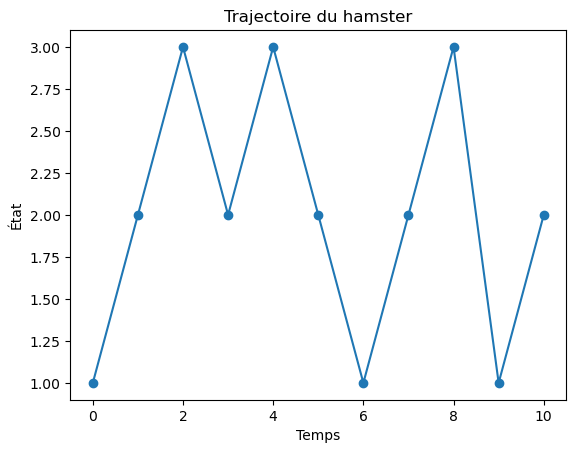

In [ ]:
import matplotlib.pyplot as plt
x0 = 1
n=10
traj = SimuTrajectoire(x0, A, n)

plt.plot(traj, marker='o')
plt.title("Trajectoire du hamster")
plt.xlabel("Temps")
plt.ylabel("État")
plt.show()

# Partie 3 : L'équilibre aux limites et comportement asymptotique

**Question 22 :** Lorsqu'on possède la matrice de transition $A^n$, renommée avec `M`, quelle serait la relation directe menant au vecteur probabiliste $V_n$ calculé ?

### III. Comportement asymptotique du hamster

On veut étudier le comportement de la loi de $X_n$ quand $n \to +\infty$.

On note :
$$
V_n = V_0 A^n
$$

---

### 🔹 Question : calcul de $V_n$

Si la matrice $A^n$ est stockée dans une variable `M`, alors :

$$
V_n = V_0 M
$$

---

### 🔹 Appel Python correspondant

On suppose :
- `V0` = vecteur ligne initial
- `M` = matrice $A^n$

```python
Vn = V0.dot(M)

**Question 23 :** Produisez et finalisez le bloc de code qui vise à construire `PremTermesLoiXn`.

In [11]:
import numpy as np

def PremTermesLoiXn(x0, A, n):
    
    V = np.zeros((n+1, 3))
    V0 = np.zeros(3)
    V0[x0 - 1] = 1
    
    M = np.eye(3)
    
    for k in range(n+1):
        V[k] = V0.dot(M)  
        M = np.dot(M, A)
    
    return V

**Question 24 :** En compilant et visualisant l'évolution à long terme, dressez une ou de plusieurs conjectures par rapport au résultat visualisé.

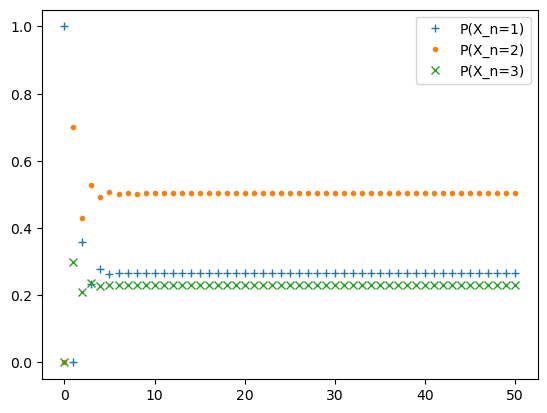

In [12]:
n = 50
x0 = 1
Y = range(n+1)
V = PremTermesLoiXn(x0, A, n)
plt.plot(Y, V[:,0], '+', label='P(X_n=1)')
plt.plot(Y, V[:,1], '.', label='P(X_n=2)')
plt.plot(Y, V[:,2], 'x', label='P(X_n=3)')
plt.legend(loc='best')

### Conjecture à partir du graphe

On observe que les trois courbes représentant :
- $P(X_n = 1)$
- $P(X_n = 2)$
- $P(X_n = 3)$

se stabilisent lorsque $n$ devient grand.

---

On peut dire que : 
- Les probabilités ne continuent plus à fluctuer
- Elles convergent vers des valeurs constantes
- Cette limite semble indépendante de l’état initial

---

### Conjecture

On peut conjecturer l’existence d’un vecteur $\pi = (\pi_1,\pi_2,\pi_3)$ tel que :

$$
V_n \xrightarrow[n \to +\infty]{} \pi
$$
$$
P(X_n​=k) \xrightarrow[n \to +\infty]{} \pi_k
$$
---

### Interprétation

Cela signifie que la chaîne de Markov admet une **distribution stationnaire**.

À long terme, le hamster évolue vers un comportement stable :
les probabilités d’être dans chaque état deviennent constantes, indépendamment de l’état initial.

#### - `En admettant que (Xn) converge en loi vers une v.a.r. X qui ne dépend pas de x0 et en notant π= P([X = 1]) P([X = 2]) P([X = 3]). Que peut-on dire de π?`

### Propriété fondamentale

Comme $V_n = V_0 A^n$ et que $V_n$ converge vers $\pi$, on a :

$$
\pi = \pi A
$$

---

### Interprétation

Le vecteur $\pi$ est une **distribution stationnaire** de la chaîne de Markov.

Cela signifie que :
- si la loi initiale est $\pi$
- alors la loi reste $\pi$ à chaque étape

---

### Conclusion

$\pi$ est un vecteur probabiliste vérifiant :

- $\pi A = \pi$
- $\pi_1 + \pi_2 + \pi_3 = 1$

Donc $\pi$ est la **loi limite stationnaire** de la chaîne de Markov.

#### - `Donner alors une approximation de π.`

On a pour n grand : 
$$
A^n \approx
\begin{pmatrix}
0.27 & 0.50 & 0.23 \\
0.27 & 0.50 & 0.23 \\
0.27 & 0.50 & 0.23
\end{pmatrix}
$$

---

Soit : 

$$
V_n = V_0 A^n
$$

Quand $n \to +\infty$, on obtient :

$$
V_n \to \pi
$$

Donc toutes les lignes de $A^n$ tendent vers $\pi$.

---

### Approximation de $\pi$

On en déduit directement :

$$
\pi \approx (0.27,\; 0.50,\; 0.23)
$$
La chaîne de Markov converge vers cette distribution stationnaire.

#### - `Que peut-on en conclure sur le comportement à terme du hamster?`

### Conclusion sur le comportement à terme du hamster

À partir du résultat précédent, on obtient que la loi de $X_n$ converge vers une distribution stationnaire :

$$
\pi \approx (0.27,\; 0.50,\; 0.23)
$$

---

### Interprétation

À long terme :

- le hamster ne reste pas bloqué dans un état particulier
- il continue de changer d’état de manière aléatoire
- mais les proportions de temps passées dans chaque état deviennent stables

---

### Conclusion

Le comportement du hamster devient **stationnaire** :

- environ **27% du temps** à manger  
- environ **23% du temps** à dormir  
- environ **50% du temps** sur la roue  

Et surtout, ce comportement est **indépendant de l’état initial**.